In [1]:
# Connect / Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import Library
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load Dataset (CSV) from Google Drive
file_path = '/content/drive/My Drive/marketing_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,Date,User_ID,Location,Visit,Session_Duration,Product_Category,Product_Page_Views,Ads_Name,Impressions,Clicks,Engagement,Purchase,Transaction_Amount,Repeat_Customer
0,2025-05-11,6182f347-533f-4a72-b64f-a54a8c611654,Yogyakarta,2,2,Shirt,2,Campaign C,968,198,12,0,0,0
1,2024-10-18,4b7e6b3c-87d2-42a6-98ee-ac2bfe9fecaa,Medan,2,14,Pants,1,Campaign C,158,17,6,0,0,0
2,2024-09-14,6e218b09-9afd-4015-816b-cb9f7426b193,Denpasar,1,2,Accessory,9,Campaign A,991,113,15,0,0,0
3,2025-06-19,1d4a3d81-b3a7-40e0-8b08-587d1963c26d,Semarang,3,12,Accessory,7,Campaign A,997,43,32,0,0,0
4,2024-12-20,e0b15aba-a6a2-4967-a79b-44b6da509fed,Yogyakarta,1,14,Accessory,4,Campaign C,452,197,44,0,0,0


# **Data Summary**

In [3]:
# Display concise summary of the DataFrame including column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                2000 non-null   object
 1   User_ID             2000 non-null   object
 2   Location            2000 non-null   object
 3   Visit               2000 non-null   int64 
 4   Session_Duration    2000 non-null   int64 
 5   Product_Category    2000 non-null   object
 6   Product_Page_Views  2000 non-null   int64 
 7   Ads_Name            2000 non-null   object
 8   Impressions         2000 non-null   int64 
 9   Clicks              2000 non-null   int64 
 10  Engagement          2000 non-null   int64 
 11  Purchase            2000 non-null   int64 
 12  Transaction_Amount  2000 non-null   int64 
 13  Repeat_Customer     2000 non-null   int64 
dtypes: int64(9), object(5)
memory usage: 218.9+ KB


# **Check for Duplicate & Missing Values**

In [4]:
# Check the number of duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# View duplicate rows if any exist
df.duplicated()

Number of duplicate rows: 0


,0
0,False
1,False
2,False
3,False
4,False
...,...
1995,False
1996,False
1997,False
1998,False


In [5]:
# Count missing values per column
df.isnull().sum()

,0
Date,0
User_ID,0
Location,0
Visit,0
Session_Duration,0
Product_Category,0
Product_Page_Views,0
Ads_Name,0
Impressions,0
Clicks,0


# **Descriptive Statistics**

In [6]:
# Check the descriptive statistics for selected numerical columns
numeric_cols = [
    "Visit",
    "Session_Duration",
    "Product_Page_Views",
    "Impressions",
    "Clicks",
    "Engagement",
    "Purchase",
    "Transaction_Amount",
    "Repeat_Customer"
]

df[numeric_cols].describe()

,Visit,Session_Duration,Product_Page_Views,Impressions,Clicks,Engagement,Purchase,Transaction_Amount,Repeat_Customer
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,2.510000,7.530500,4.963500,559.44450,103.679000,24.475000,0.03000,3.419000,0.008000
std,1.132052,4.013867,2.575749,260.08986,54.876066,14.316629,0.17063,21.985202,0.089107
min,1.000000,1.000000,1.000000,100.00000,10.000000,0.000000,0.00000,0.000000,0.000000
25%,1.000000,4.000000,3.000000,338.75000,57.000000,13.000000,0.00000,0.000000,0.000000
50%,3.000000,8.000000,5.000000,568.50000,103.000000,24.000000,0.00000,0.000000,0.000000
75%,4.000000,11.000000,7.000000,782.00000,151.000000,37.000000,0.00000,0.000000,0.000000
max,4.000000,14.000000,9.000000,999.00000,199.000000,49.000000,1.00000,199.000000,1.000000


• Based on the descriptive statistics of the selected columns, the dataset appears clean and free from issues. **There are no missing values, as the count for all numerical columns is 2000, which matches the total number of records**.

• For metrics such as Visit, Session Duration, Product Page Views, Impressions, Clicks, and Engagement, **the mean and median values are relatively close, indicating that the data distribution is fairly symmetrical and not heavily influenced by extreme values**. For example, the average Visit is 2.51 with a median of 3, Session Duration has a mean of 7.53 and a median of 8, and Product Page Views shows a mean of 4.96 and a median of 5. A similar pattern appears in Impressions with a mean of 559.44 and a median of 568.50, Clicks with a mean of 103.68 and a median of 103, and Engagement with a mean of 24.47 and a median of 24. These close values suggest that user behavior on the platform is relatively stable and representative.

• **In contrast, variables related to transactions such as Purchase, Transaction Amount, and Repeat Customer display a noticeable gap between the mean and median**. The median is 0 because most users did not make a purchase, while the mean is slightly higher due to a small portion of users who completed transactions with significant values. This imbalance indicates that the data distribution is heavily right skewed. **However, this pattern is common in e commerce data and does not indicate any data issues**. Instead, it provides meaningful insights that will be valuable for the marketing dashboard that will be developed.

# **Data Distribution**

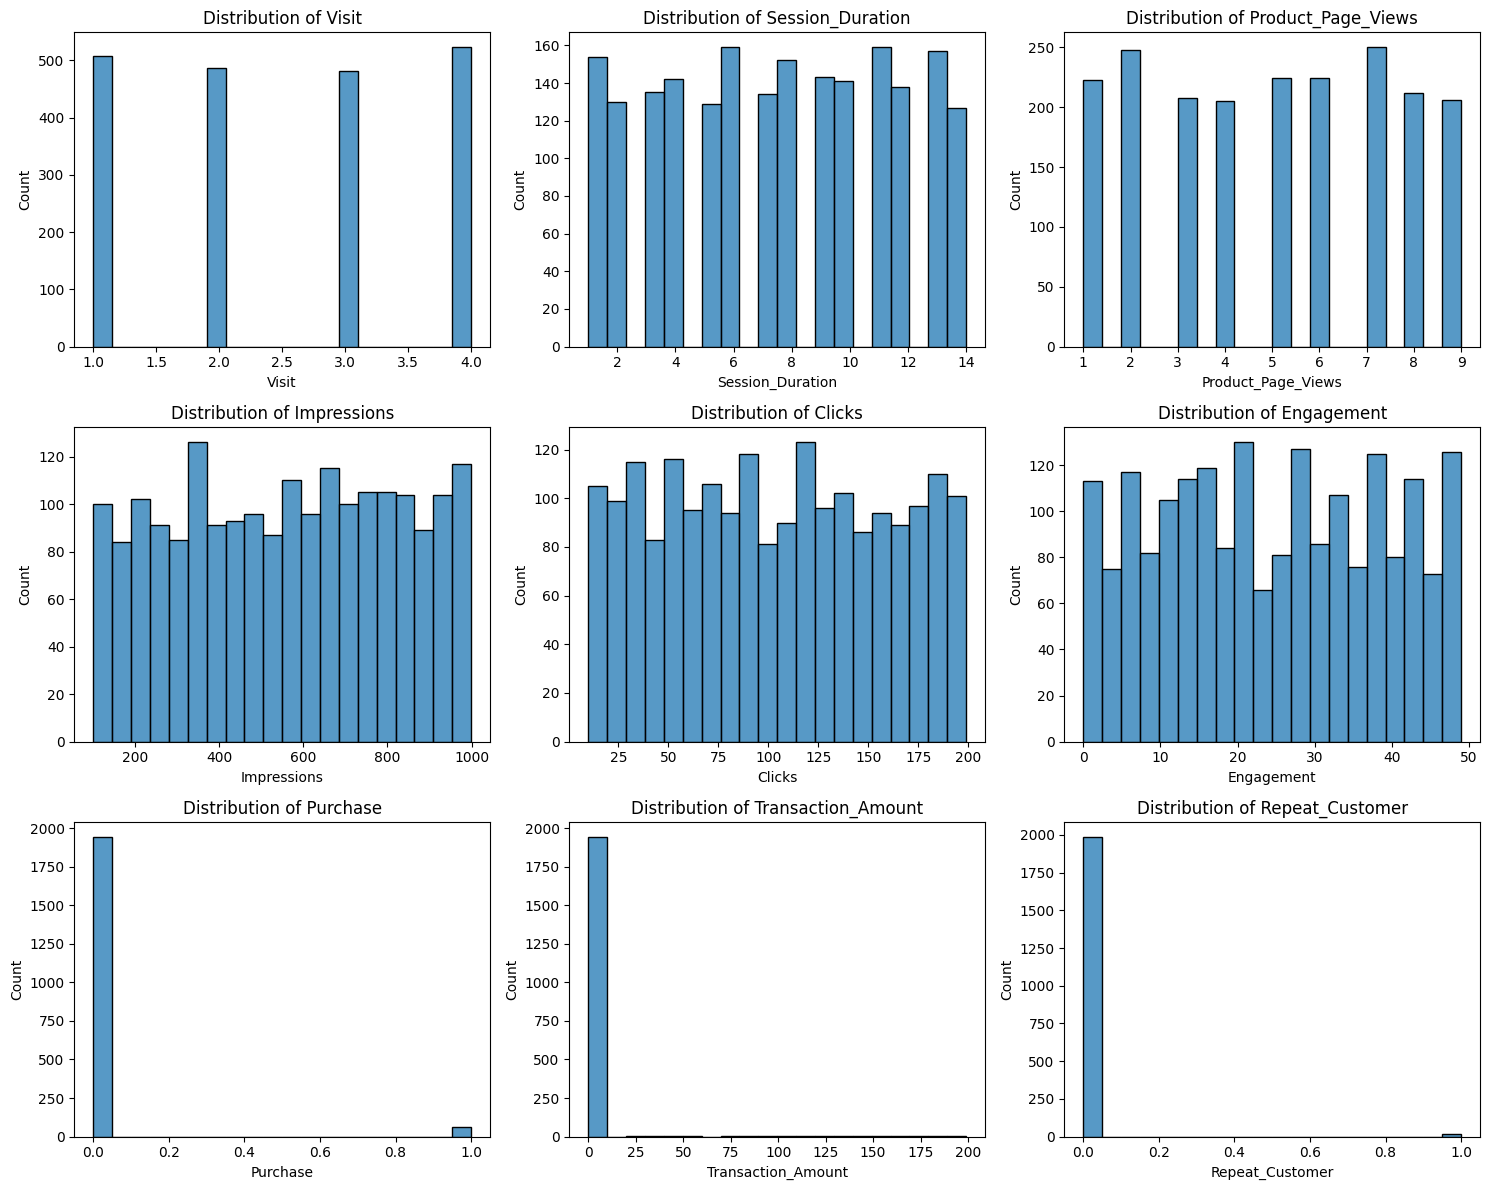

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = [
    "Visit",
    "Session_Duration",
    "Product_Page_Views",
    "Impressions",
    "Clicks",
    "Engagement",
    "Purchase",
    "Transaction_Amount",
    "Repeat_Customer"
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

plt.show()



*   **The distribution of key behavioral metrics** (Visit, Session Duration, Product Page Views, Impressions, Clicks, and Engagement) appears **stable and well-balanced across realistic value ranges**, indicating consistent data capture with **no visible anomalies** such as extreme spikes, gaps, or distorted patterns.
*   Purchase and Repeat_Customer appropriately show a **strong dominance of non-conversion values** (0), which **aligns with typical e-commerce behavior** where only a smaller portion of users actually convert or return. Meanwhile, **Transaction_Amount exhibits a right-skewed pattern, reflecting the natural tendency for most transactions to occur at lower values**, with fewer high-value purchases.
*   Overall, the dataset is ready for the next analytical stage.











# **Checking the Data Outliers**

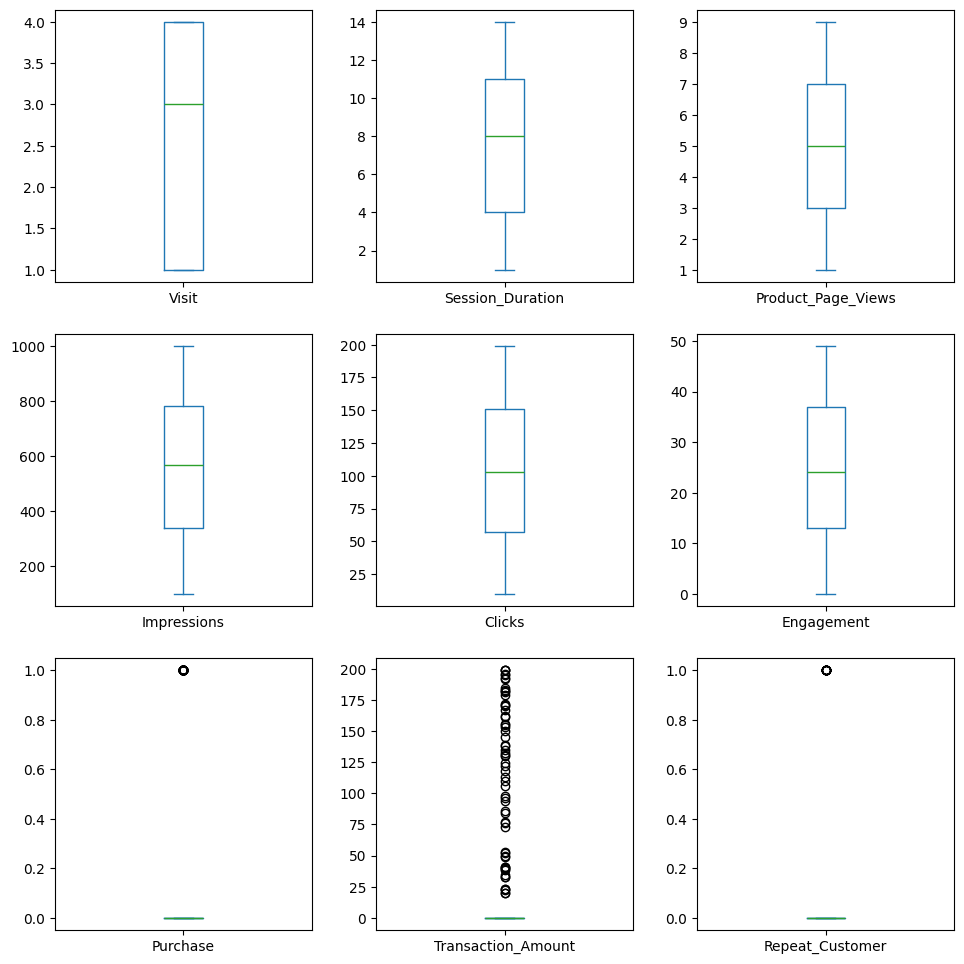

In [8]:
df[columns_to_plot].plot(
    kind="box",
    figsize=(10, 10),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
)

plt.tight_layout(pad=2)

*   The boxplots for the **main behavioral metrics** (Session Duration, Product Page Views, Impressions, Clicks, and Engagement) show **no visible outliers**.
*   **Transaction_Amount is the only variable that displays several high-end outliers**. **This pattern is expected in an e-commerce context**, where a small proportion of customers accounts for disproportionately high transaction values. These extreme observations are therefore informative rather than problematic, as they may be linked to high-impact campaigns, premium customer segments, or bulk purchases. Removing them would risk eliminating meaningful business insights.
*  **The binary variables (Purchase and Repeat_Customer) show a strong class imbalance dominated by the value 0**. **This distribution accurately reflects a realistic business/marketing funnel**, in which most visitors do not convert or become repeat customers. The isolated values of 1 in the boxplot are not anomalies but represent successful conversion and retention events, making these variables critical indicators of campaign effectiveness and overall customer journey performance.